# Building legal characteristics on top of aviation network



## PART 1: connecting to memgraph; building aviation/legal search vocabulary 

difference with fien- don't aggregate the edges- retain document details for context later

In [136]:
# imports
from neo4j import GraphDatabase
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import networkx as nx
import scipy
from IPython.display import Image, display
import seaborn as sns
import re
from pathlib import Path
from collections import Counter
import json

In [137]:
# connection to graph
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("", ""))

In [138]:
# creation of functions for easy Cypher running via VSC

def run_query(cypher, params=None):
    """
    Run a Cypher query and return results as a pandas DataFrame.
    """
    with driver.session() as session:
        result = session.run(cypher, params or {})
        return pd.DataFrame([dict(r) for r in result])


# Verify connection and confirm full import
counts = run_query("""
    MATCH (n)
    RETURN count(n) AS node_count
""")

edge_counts = run_query("""
    MATCH ()-[r]->()
    RETURN count(r) AS edge_count
""")

print("Connected to Memgraph.")
print(f"Nodes : {counts['node_count'][0]:,}  (expected 546,648)")
print(f"Edges : {edge_counts['edge_count'][0]:,}  (expected 1,432,277)")

Connected to Memgraph.
Nodes : 546,648  (expected 546,648)
Edges : 1,432,277  (expected 1,432,277)


In [152]:
df_edge_count = run_query("""
MATCH ()-[r:RELATED_TO]->()
RETURN count(r) AS related_to_edges
""")

df_edge_count

,related_to_edges
0,106812


In [74]:
# for use of python lists with Cypher
def to_cypher_list(lst):
    return '[' + ', '.join(f'"{item}"' for item in lst) + ']'

### Search Vocabulary

In [ ]:
## LISTS DEFIENED FOR ELABORATION AVIATON NETWORKS

# (1) EPSTEIN NAMES - defining all names for epstein (all nodes we identified that represent Epstein)
EPSTEIN_NAMES = ["Jeffrey Epstein", "Jeff Epstein", "Epstein"]

# (2) AVIATION ACTIONS
AVIATION_ACTIONS = [
    # Core travel with person
    'traveled with',
    'traveled_with',
    'travelled with',
    'accompanied',
    'accompanied by',
    'traveled to Little St James with',
    'traveled with to multiple residences',
    'traveled with on private plane',
    'traveled to Caribbean location with',
    'traveled to Europe with',
    'traveled extensively with',
    'traveled internationally with',
    'traveled internationally on private jet with',
    'traveled by private jet with',
    'traveled on private jet with',
    'traveled on private jet of',
    'traveled on private airplane with',
    'traveled on private plane with',
    'traveled on aircraft with',
    'traveled on jet owned by',
    'traveled on jet of',
    'traveled on flight with',
    'traveled on plane with',
    'traveled on planes in interstate commerce related to',
    'traveled aboard planes and boats of',
    'traveled via private jet of',
    'traveled via private aircraft with',
    'traveled on private aircraft owned by',
    'traveled on aircraft owned by',
    'traveled by helicopter provided by',
    # Flew variants
    'flew',
    'flew with',
    'flew_with',
    'flew on',
    'flew to',
    'flew on jet of',
    'flew on private jet of',
    'flew on private jet owned by',
    'flew on private jet to Africa',
    'flew on private jet',
    'flew on private plane of',
    'flew on airplane of',
    'flew on plane of',
    'flew on plane owned by',
    'flew on plane',
    'flew as passenger on',
    'flew to Africa',
    'flew to Africa with',
    'flew to South Africa with',
    'flew to and represented',
    'flew internationally with',
    'flew internationally to meet',
    'flew two young women to dinner to entertain',
    'flew with as passenger on aircraft owned by',
    'flew Gulfstream to',
    'flew with pilot',
    'allegedly flew',
    'allegedly flew victim to',
    'allegedly flew victims to',
    'allegedly flew to London',
    'allegedly flew for entertainment purposes to',
    # Transported variants
    'transported via private jet',
    'transported on private jet with',
    'transported via private aircraft as',
    'transported to Africa',
    'transported and sexually abused',
    'transported victim via',
    'transported victims via',
    'transported young girls via private aircraft with',
    'transported underage females across state lines using',
    'transported to various properties',
    'transported with',
    'transported to',
    'was transported via private jet by',
    'was transported to residence of',
    'allegedly transported for sexual purposes to',
    'allegedly transported and coerced',
    'allegedly transported victim with',
    'allegedly transported minors on',
    # Aircraft/jet specific
    'entertained on private jet',
    'hosted on private aircraft',
    'provided private jet travel to',
    'provided flights on jets to',
    'provided private jet to',
    'provided private jet for transport of',
    'provided private jet service to',
    'provided transportation via private jet to',
    'provided air transport to',
    'provided aircraft for travel with',
    'provided aircraft to',
    'offered transportation via private jet to',
    'offered jet ride to',
    'offered jet ride',
    'offered jet transport to',
    'offered jet charter to',
    'offered ride to Europe on jet',
    'invited to fly on private jet',
    'flew with as passenger on aircraft owned by',
    'boarded aircraft with',
    'arrived at private aircraft with',
    'ceased flying on aircraft with',
    'chartered private plane to transport guests to',
    'chartered private aircraft for',
    'used jet provided by',
    'used aircraft to transport to Africa',
    'operated Boeing aircraft with',
    'operated private airplane transporting',
    'began international travel with',
    'began traveling with',
    'traveled with Jeffrey Epstein',
    'hosted private jet flight for',
    'stepped away from royal jet and offered BBJ opportunity',
    # Flight log references
    'appears on flight logs with',
    'appeared in flight logs of',
    'appeared_in_flight_logs_of',
    'appeared on flight log with',
    'appeared on flight logs of',
    # Allegedly traveled
    'allegedly traveled with victim to',
    'allegedly arranged helicopter travel for',
    'allegedly instructed to travel and engage in sexual activity with',
    # Recruited and transported
    'recruited and transported to',
    'recruited and transported minors for',
    'recruited and transported girls to',
    'recruited and transported girls for',
    'recruited and transported underage girls for',
    'coordinated recruitment and transport to',
    # added after a second time feeding all actions to claude to verify answer
    'traveled with and attended to',
    'traveled internationally with and exploited for sex acts',
    'traveled to and exploited victims at',
    'traveled to and resided in',
    'traveled to during house arrest on',
    'traveled regularly with',
    'flew on private aircraft owned by',
    'transported on aircraft','hosted and transported to',
    'accepted air travel from',
    'accepted air transportation from',
    'directed to travel to and provide sexual services at',
    'directed to travel to island',
]

# (5) NOISE TERMS
NOISE_TERMS = [
    'jet', 'plane', 'aircraft', 'helicopter', 'island', 'ranch', 'apartment',
    'conference', 'driver', 'therapist',
    'real estate', 'property', 'NU', "victims' rights",'London',
    'multiple properties',
    'sexual assaults',
    'dinner event',
    'modeling agency',
]

## PART 2: Helper Functions
- remove noise from aviation search
- consolidate aliases
- pool document categories
- aggregate edges

In [76]:
## removal of noise entities from aviation network
def is_noise_entity(name):
    if name is None:
        return True
    name_lower = name.lower()
    return any(term.lower() in name_lower for term in NOISE_TERMS)


In [168]:
## consolidation of double entities in aviation network
ENTITY_CONSOLIDATION = {
    # Bill Clinton
    'President Clinton': 'Bill Clinton',
    # Alan Dershowitz
    'Professor Dershowitz': 'Alan M. Dershowitz',
    'Alan Dershowitz and Tatiana': 'Alan M. Dershowitz',
    # Lawrence Summers
    'Lawrence Henry Summers': 'Lawrence Summers',
    # Andrés Pastrana
    'Andrés Pastrana': 'Andrés Pastrana Arango',
    # Virginia Giuffre
    'Virginia L. Giuffre': 'Virginia Roberts Giuffre',
    'Virginia': 'Virginia Roberts Giuffre',
    # Thorbjørn Jagland
    'Thorbjorn Jagland': 'Thorbjørn Jagland',
    # Jean-Luc Brunel
    'Jean Luc Brunel': 'Jean-Luc Didier Henri-Rene Brunel',
}

def consolidate_entity(name):
    return ENTITY_CONSOLIDATION.get(name, name)

In [170]:
## pooling of document categories
DOC_CATEGORY_MAP = {

    # LEGAL / OFFICIAL
    "court_filing": "legal",
    "legal_filing": "legal",
    "transcript": "legal",
    "public_record": "legal",
    "public_records": "legal",

    # MEDIA / SECONDARY SOURCES
    "media_article": "media",
    "report": "media",
    "book_excerpt": "media",

    # DIRECT COMMUNICATION
    "email": "communication",
    "letter": "communication",
    "memorandum": "communication",

    # FINANCIAL / BUSINESS
    "financial_document": "financial",

    # MIXED / UNCERTAIN
    "mixed_document": "mixed",
    "other": "other"
}

def map_document_group(category):
    if pd.isna(category):
        return "unknown"
    
    category = str(category).strip()
    
    return DOC_CATEGORY_MAP.get(category, "other")


In [171]:
## function to build edge table from event-level data

def build_edge_table(df_events):

    edge_records = []

    for (n1, n2), group in df_events.groupby(["node_1", "node_2"]):

        # Count each document only once per edge
        doc_groups = (
            group[["doc_id", "document_group"]]
            .dropna(subset=["doc_id"])
            .drop_duplicates()
        )

        group_counter = Counter(doc_groups["document_group"])

        weight = group["doc_id"].nunique()

        legal_weight = group_counter.get("legal", 0)

        legal_prop = (
            legal_weight / weight
            if weight > 0 else 0
        )

        dominant_document_group = (
            group_counter.most_common(1)[0][0]
            if weight > 0 else "unknown"
        )

        edge_records.append({
            "source": n1,
            "target": n2,
            "weight": weight,
            "claim_count": group["claim_id"].nunique(),
            "legal_weight": legal_weight,
            "legal_prop": legal_prop,
            "dominant_document_group": dominant_document_group,
        })

    return pd.DataFrame(edge_records)


## PART 3: Building Event-level aviation network

### Wide net aviation network construction

In [154]:
# First pass build of aviation events dataframe

df_aviation_events = run_query(f"""
MATCH (epstein:Entity)-[r:RELATED_TO]-(other:Entity)
WHERE epstein.name IN {to_cypher_list(EPSTEIN_NAMES)}
AND r.action IN {to_cypher_list(AVIATION_ACTIONS)}

OPTIONAL MATCH (d:Document {{doc_id: r.doc_id}})

RETURN
    epstein.name AS epstein_name,
    other.name AS entity,
    other.entity_type AS entity_type,
    r.action AS action,
    r.timestamp AS timestamp,
    r.doc_id AS doc_id,
    r.claim_id AS claim_id,
    r.sequence_order AS sequence_order,
    d.category AS document_category,
    d.file_path AS file_path,
    d.paragraph_summary AS paragraph_summary
ORDER BY timestamp, entity
""")

print(f"Raw event-level aviation edges: {len(df_aviation_events):,}")
print("Raw unique entities:", df_aviation_events["entity"].nunique())

# Remove noise entities
df_aviation_events = (
    df_aviation_events[
        ~df_aviation_events["entity"].apply(is_noise_entity)
    ]
    .reset_index(drop=True)
)

print(f"After noise filter: {len(df_aviation_events):,}")

# Consolidate duplicate / alternative entity names
df_aviation_events["entity_original"] = df_aviation_events["entity"]
df_aviation_events["entity"] = df_aviation_events["entity"].apply(consolidate_entity)

print(
    "Unique entities before consolidation:",
    df_aviation_events["entity_original"].nunique()
)

print(f"aviation edges after consolidation: {len(df_aviation_events):,}")

print(
    "Unique entities after consolidation:",
    df_aviation_events["entity"].nunique()
)

# Add document groups to aviation events
df_aviation_events["document_group"] = (
df_aviation_events["document_category"].apply(map_document_group))

Raw event-level aviation edges: 290
Raw unique entities: 92
After noise filter: 264
Unique entities before consolidation: 69
aviation edges after consolidation: 264
Unique entities after consolidation: 60


### Manually review nodes to prune and select actors

In [156]:
aviation_entity_review = (
    df_aviation_events
    .groupby("entity")
    .agg(
        aviation_claims=("claim_id", "nunique"),
        aviation_docs=("doc_id", "nunique"),
        actions=("action", lambda x: sorted(set(x))[:10]),
        document_groups=("document_group", lambda x: sorted(set(x)))
    )
    .reset_index()
    .sort_values("aviation_docs", ascending=False)
)
aviation_entity_review.head(60)

,entity,aviation_claims,aviation_docs,actions,document_groups
4,Bill Clinton,100,88,"[accepted air travel from, accompanied, allege...","[communication, legal, media, mixed]"
34,Virginia Roberts Giuffre,19,15,[allegedly instructed to travel and engage in ...,"[communication, legal, media, mixed]"
12,Ghislaine Maxwell,14,14,"[accompanied, accompanied by, allegedly transp...","[communication, legal, media, mixed]"
22,Kevin Spacey,14,14,"[flew, flew to Africa, flew to South Africa wi...","[legal, media]"
2,Alan M. Dershowitz,14,11,"[appeared on flight log with, appeared_in_flig...","[communication, legal, media]"
8,Chris Tucker,10,10,"[flew, flew to Africa, flew to South Africa wi...","[legal, media]"
28,"Prince Andrew, Duke of York",8,8,"[allegedly flew, entertained on private jet, f...","[communication, legal, media, mixed]"
24,Lawrence Summers,9,7,"[accepted air transportation from, flew on, fl...","[communication, media, mixed]"
41,unknown person A,6,6,"[flew, hosted private jet flight for, transpor...","[communication, legal, media]"
33,Thorbjørn Jagland,5,5,"[offered jet ride, offered jet ride to, offere...",[media]


In [173]:
# Curated core aviation actor set

AVIATION_CORE_ACTORS = [

    "Adriana Mucinska",
    "Al Gore",
    "Alan M. Dershowitz",
    "Andrés Pastrana Arango",
    "Bill Clinton",
    "Bill Richardson",
    "Chris Tucker",
    "Donald Trump",
    "Ehud Barak",
    "Ghislaine Maxwell",
    "Haley Robson",
    "Heidi Klum",
    "Jean-Luc Didier Henri-Rene Brunel",
    "Kevin Spacey",
    "Lawrence Summers",
    "Matt Groening",
    "Nadia Marcinkova",
    "Naomi Campbell",
    "Prince Andrew, Duke of York",
    "Sandy Berger",
    "Sarah Kellen",
    "Thorbjørn Jagland",
    "Virginia Roberts Giuffre"
]

ACTOR_CATEGORY_MAP = {
    # Epstein inner circle / associates
    "Ghislaine Maxwell": "Epstein associate",
    "Haley Robson": "Epstein associate",
    "Nadia Marcinkova": "Epstein associate",
    "Sarah Kellen": "Epstein associate",
    "Adriana Mucinska": "Epstein associate",
    "Alan M. Dershowitz": "Epstein associate",
    "Virginia Roberts Giuffre": "Epstein associate",
    "Jean-Luc Didier Henri-Rene Brunel": "Epstein associate",


    # Political / public office
    "Al Gore": "political",
    "Andrés Pastrana Arango": "political",
    "Bill Clinton": "political",
    "Bill Richardson": "political",
    "Donald Trump": "political",
    "Ehud Barak": "political",
    "Prince Andrew, Duke of York": "political",
    "Sandy Berger": "political",
    "Thorbjørn Jagland": "political",
    "Lawrence Summers": "political",

    # Entertainment / media / celebrity
    "Chris Tucker": "celebrity/media",
    "Heidi Klum": "celebrity/media",
    "Kevin Spacey": "celebrity/media",
    "Matt Groening": "celebrity/media",
    "Naomi Campbell": "celebrity/media",

}

In [174]:
# Curated aviation actor dataframe

df_aviation_curated = (
    df_aviation_events[
        df_aviation_events["entity"].isin(AVIATION_CORE_ACTORS)
    ]
    .copy()
    .reset_index(drop=True)
)

print(f"Rows: {len(df_aviation_curated):,}")
print(f"Unique actors: {df_aviation_curated['entity'].nunique()}")

print("\nActors retained:")
print(sorted(df_aviation_curated["entity"].unique()))

Rows: 213
Unique actors: 22

Actors retained:
['Adriana Mucinska', 'Al Gore', 'Alan M. Dershowitz', 'Andrés Pastrana Arango', 'Bill Clinton', 'Bill Richardson', 'Chris Tucker', 'Donald Trump', 'Ehud Barak', 'Ghislaine Maxwell', 'Haley Robson', 'Heidi Klum', 'Jean-Luc Didier Henri-Rene Brunel', 'Kevin Spacey', 'Lawrence Summers', 'Nadia Marcinkova', 'Naomi Campbell', 'Prince Andrew, Duke of York', 'Sandy Berger', 'Sarah Kellen', 'Thorbjørn Jagland', 'Virginia Roberts Giuffre']


### Find all relationships between main actors throughout full network

In [89]:
# Full aviation network search:
# Epstein aliases + curated aviation actor aliases
# This captures both:
# 1. Epstein ↔ curated actors
# 2. curated actor ↔ curated actor

aviation_core_original_names = (
    df_aviation_curated["entity_original"]
    .dropna()
    .unique()
    .tolist()
)

full_aviation_query_names = sorted(
    set(aviation_core_original_names + EPSTEIN_NAMES)
)

print(f"Original curated actor names: {len(aviation_core_original_names)}")
print(f"Full aviation query names incl. Epstein aliases: {len(full_aviation_query_names)}")


df_aviation_full_events = run_query(f"""
MATCH (a:Entity)-[r:RELATED_TO]-(b:Entity)

WHERE a.name IN {to_cypher_list(full_aviation_query_names)}
AND b.name IN {to_cypher_list(full_aviation_query_names)}

OPTIONAL MATCH (d:Document {{doc_id: r.doc_id}})

RETURN
    a.name AS source,
    b.name AS target,
    r.action AS action,
    r.timestamp AS timestamp,
    r.doc_id AS doc_id,
    r.claim_id AS claim_id,
    r.sequence_order AS sequence_order,
    d.category AS document_category,
    d.file_path AS file_path,
    d.paragraph_summary AS paragraph_summary

ORDER BY source, target, timestamp
""")

print(f"Raw full aviation event rows: {len(df_aviation_full_events):,}")

df_aviation_full_events.head()

Original curated actor names: 31
Full aviation query names incl. Epstein aliases: 34
Raw full aviation event rows: 8,272


,source,target,action,timestamp,doc_id,claim_id,sequence_order,document_category,file_path,paragraph_summary
0,Adriana Mucinska,Alan M. Dershowitz,traveled on flight #1843 with,2005-11-17,HOUSE_OVERSIGHT_016200,HOUSE_OVERSIGHT_016200:7,7,court_filing,data/new_docs_nov2024_processed/tranche_012/HO...,This document is a court filing (Case 1:19‑cv‑...
1,Adriana Mucinska,Alan M. Dershowitz,invoked Fifth Amendment when asked about,None,HOUSE_OVERSIGHT_021824_part1,HOUSE_OVERSIGHT_021824_part1:8,8,transcript,data/001_split/HOUSE_OVERSIGHT_021824_part1.txt,This is a videotaped deposition transcript fro...
2,Adriana Mucinska,Bill Clinton,traveled with,None,HOUSE_OVERSIGHT_010593,HOUSE_OVERSIGHT_010593:3,3,report,data/new_docs_nov2024_processed/tranche_006/HO...,The document is a fragment of a House Oversigh...
3,Adriana Mucinska,Bill Clinton,flew with,None,HOUSE_OVERSIGHT_011946,HOUSE_OVERSIGHT_011946:13,13,court_filing,data/new_docs_nov2024_processed/tranche_007/HO...,The document is a collection of court‑filing e...
4,Adriana Mucinska,Bill Clinton,flew with,None,HOUSE_OVERSIGHT_013346,HOUSE_OVERSIGHT_013346:3,3,court_filing,data/new_docs_nov2024_processed/tranche_001/HO...,This excerpt from a legal filing discusses evi...


In [175]:
# Consolidate duplicate / alternative entity names in full aviation network

df_aviation_full_events["source_original"] = df_aviation_full_events["source"]
df_aviation_full_events["target_original"] = df_aviation_full_events["target"]

df_aviation_full_events["source"] = (
    df_aviation_full_events["source"]
    .apply(consolidate_entity)
)

df_aviation_full_events["target"] = (
    df_aviation_full_events["target"]
    .apply(consolidate_entity)
)

# Normalize Epstein aliases
epstein_aliases = {
    "Jeff Epstein": "Jeffrey Epstein",
    "Epstein": "Jeffrey Epstein"
}

df_aviation_full_events["source"] = df_aviation_full_events["source"].replace(epstein_aliases)
df_aviation_full_events["target"] = df_aviation_full_events["target"].replace(epstein_aliases)

print("Unique source nodes after consolidation:", df_aviation_full_events["source"].nunique())
print("Unique target nodes after consolidation:", df_aviation_full_events["target"].nunique())

Unique source nodes after consolidation: 17
Unique target nodes after consolidation: 17


In [176]:
# Canonicalize node pairs so A--B and B--A are treated as the same edge

df_aviation_full_events["node_1"] = (
    df_aviation_full_events[["source", "target"]].min(axis=1)
)

df_aviation_full_events["node_2"] = (
    df_aviation_full_events[["source", "target"]].max(axis=1)
)

# Remove exact document-level duplicates for the same unordered pair and reduce to unique documents
df_aviation_full_events = (
    df_aviation_full_events
    .drop_duplicates(subset=["node_1", "node_2", "doc_id"])
    .reset_index(drop=True)
)

print(f"Rows after canonical pair deduplication: {len(df_aviation_full_events):,}")

# Add document groups to aviation events
df_aviation_full_events["document_group"] = (
    df_aviation_full_events["document_category"]
    .apply(map_document_group)
)

# Save event-level aviation table

df_aviation_full_events.to_csv(
    "aviation_full_events_provenance.csv",
    index=False
)   

print("Saved: aviation_full_events_provenance.csv")
print(f"Rows: {len(df_aviation_full_events):,}")
print(f"Columns: {len(df_aviation_full_events.columns)}")

Rows after canonical pair deduplication: 2,761
Saved: aviation_full_events_provenance.csv
Rows: 2,761
Columns: 15


## PART 4: Building Legal Networks


### Full Aviation Network

In [177]:
df_aviation_edges = build_edge_table(df_aviation_full_events)

print(f"Aggregated aviation edges: {len(df_aviation_edges):,}")

df_aviation_edges.head()

Aggregated aviation edges: 61


,source,target,weight,claim_count,legal_weight,legal_prop,dominant_document_group
0,Adriana Mucinska,Alan M. Dershowitz,2,2,2,1.000000,legal
1,Adriana Mucinska,Bill Clinton,3,3,2,0.666667,legal
2,Adriana Mucinska,Jeffrey Epstein,1,1,0,0.000000,media
3,Al Gore,Ghislaine Maxwell,3,3,1,0.333333,media
4,Al Gore,Jeffrey Epstein,18,18,1,0.055556,communication


In [178]:
# Build full aviation NetworkX graph

G_aviation = nx.Graph()

for _, row in df_aviation_edges.iterrows():

    G_aviation.add_edge(
        row["source"],
        row["target"],
        weight=float(row["weight"]),
        claim_count=int(row["claim_count"]),
        dominant_document_group=";".join(row["dominant_document_group"]),
        legal_weight=int(row["legal_weight"]),
        legal_prop=float(row["legal_prop"])
    )   

print(f"Nodes: {G_aviation.number_of_nodes():,}")
print(f"Edges: {G_aviation.number_of_edges():,}")

Nodes: 23
Edges: 61


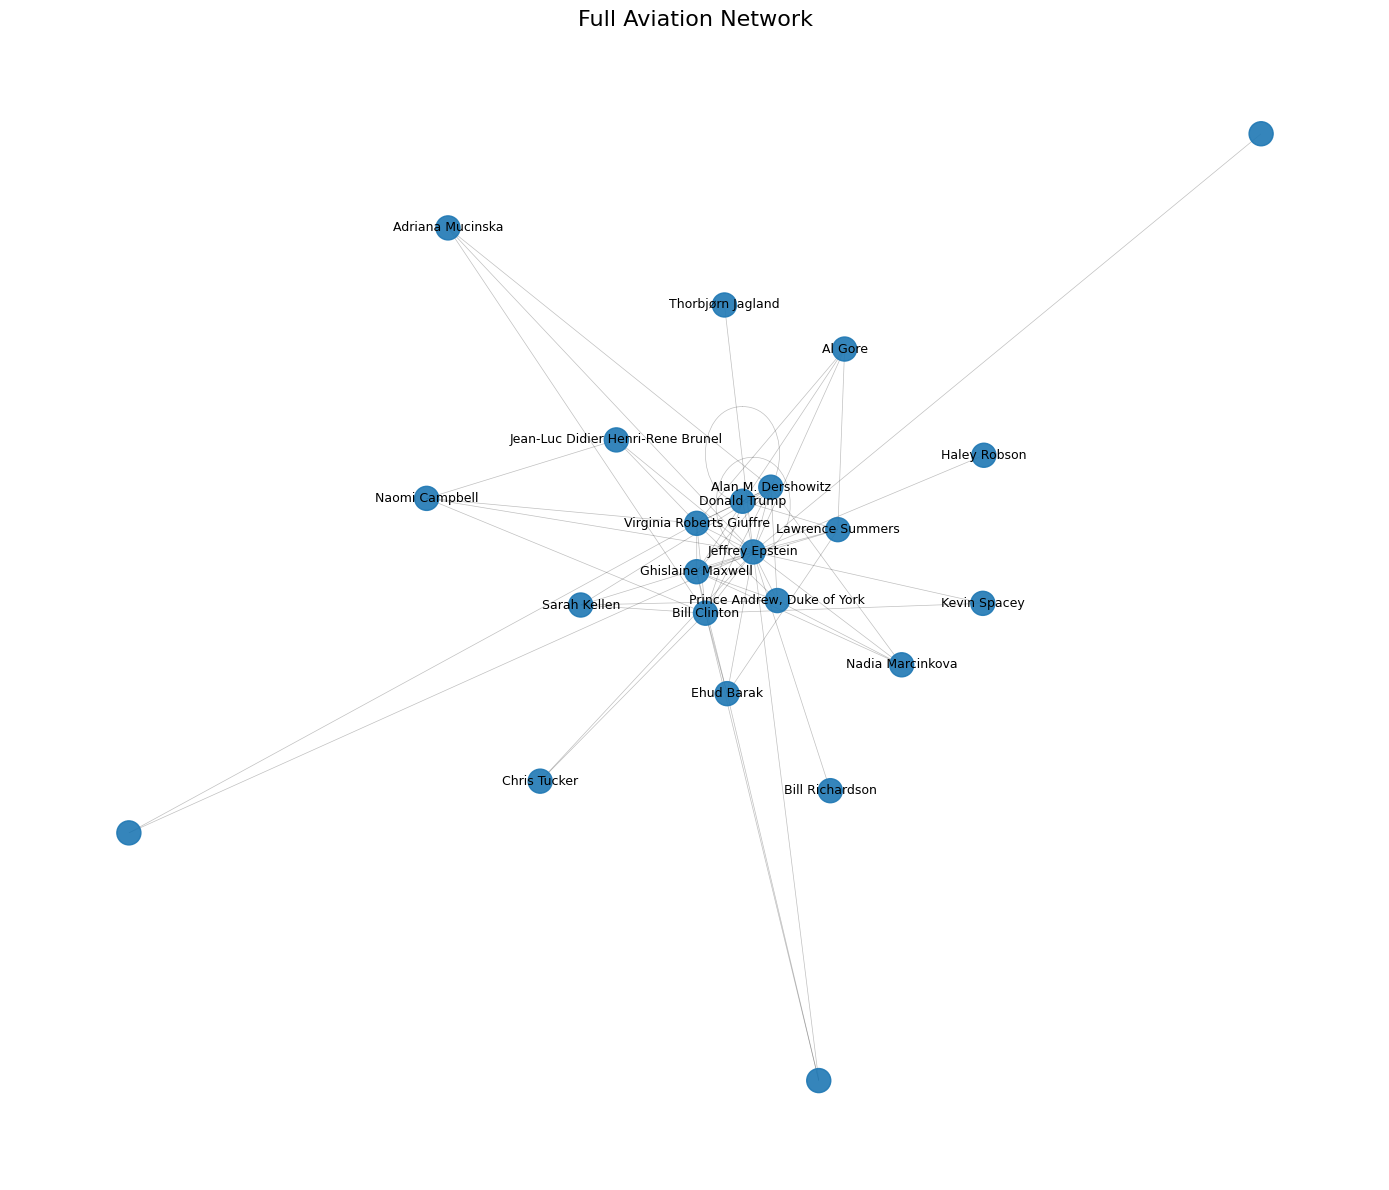

In [179]:
# Basic aviation network visualization

plt.figure(figsize=(14, 12))

pos = nx.spring_layout(
    G_aviation,
    seed=42,
    k=0.7
)

# Node sizes based on weighted degree
weighted_degree = dict(G_aviation.degree(weight="weight"))

node_sizes = [
    300 #+ 120 * weighted_degree[n]
    for n in G_aviation.nodes()
]

# Edge widths based on document-supported weight
edge_widths = [
    0.5 #+ 0.5 * G_aviation[u][v]["weight"]
    for u, v in G_aviation.edges()
]

nx.draw_networkx_edges(
    G_aviation,
    pos,
    width=edge_widths,
    alpha=0.25
)

nx.draw_networkx_nodes(
    G_aviation,
    pos,
    node_size=node_sizes,
    alpha=0.9
)

# Label strongest nodes only
top_nodes = sorted(
    weighted_degree,
    key=weighted_degree.get,
    reverse=True
)[:20]

labels = {n: n for n in top_nodes}

nx.draw_networkx_labels(
    G_aviation,
    pos,
    labels=labels,
    font_size=9
)

plt.title(
    "Full Aviation Network",
    fontsize=16
)

plt.axis("off")
plt.tight_layout()
plt.show()

### Aviation network excluding Epstein

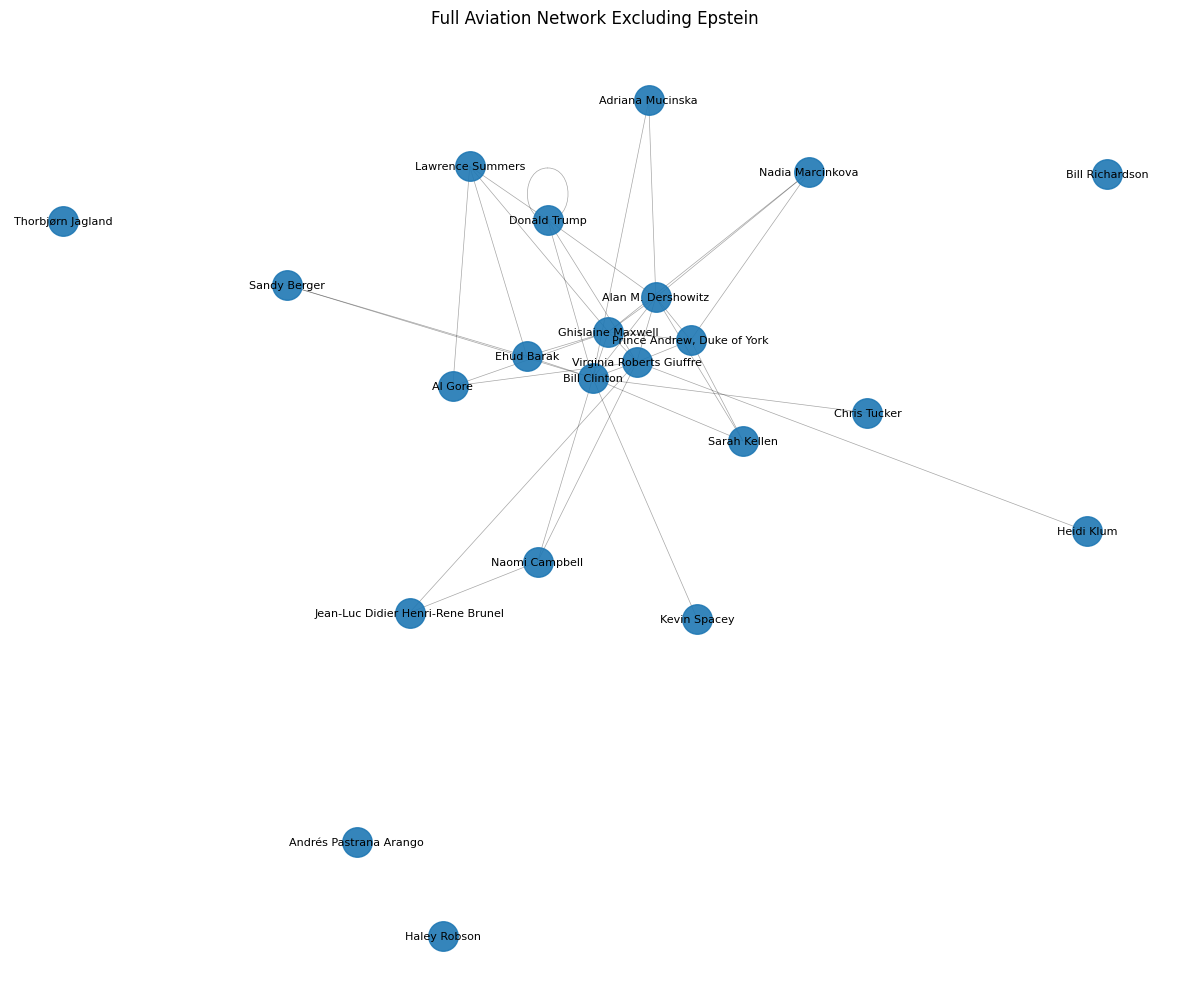

In [180]:
# Aviation network excluding Epstein for structure

G_aviation_no_epstein = G_aviation.copy()
G_aviation_no_epstein.remove_node("Jeffrey Epstein")

plt.figure(figsize=(12, 10))

pos = nx.spring_layout(
    G_aviation_no_epstein,
    seed=42,
    k=1.0
)

nx.draw_networkx_edges(
    G_aviation_no_epstein,
    pos,
    width=[
        0.5 #+ 0.6 * G_aviation_no_epstein[u][v]["weight"]
        for u, v in G_aviation_no_epstein.edges()
    ],
    alpha=0.35
)

nx.draw_networkx_nodes(
    G_aviation_no_epstein,
    pos,
    node_size=450,
    alpha=0.9
)

nx.draw_networkx_labels(
    G_aviation_no_epstein,
    pos,
    font_size=8
)

plt.title("Full Aviation Network Excluding Epstein")
plt.axis("off")
plt.tight_layout()
plt.show()

### Network build from legal documents only

In [181]:
# Legal-document subgraph among curated actors, excluding Epstein

df_legal_subgraph_events = (
    df_aviation_full_events
    .loc[df_aviation_full_events["document_group"] == "legal"]
    .copy()
)

# Remove Epstein edges
df_legal_subgraph_events = (
    df_legal_subgraph_events[
        (df_legal_subgraph_events["source"] != "Jeffrey Epstein") &
        (df_legal_subgraph_events["target"] != "Jeffrey Epstein")
    ]
    .reset_index(drop=True)
)

print(f"Legal event rows excluding Epstein: {len(df_legal_subgraph_events):,}")

Legal event rows excluding Epstein: 210


In [182]:
df_legal_subgraph_edges = build_edge_table(df_legal_subgraph_events)

print(f"Legal document-supported edges: {len(df_legal_subgraph_edges):,}")
df_legal_subgraph_edges.sort_values("weight", ascending=False).head(20)

Legal document-supported edges: 25


,source,target,weight,claim_count,legal_weight,legal_prop,dominant_document_group
10,Alan M. Dershowitz,Virginia Roberts Giuffre,59,59,59,1.0,legal
20,Ghislaine Maxwell,Virginia Roberts Giuffre,45,45,45,1.0,legal
24,"Prince Andrew, Duke of York",Virginia Roberts Giuffre,26,26,26,1.0,legal
17,Bill Clinton,Virginia Roberts Giuffre,12,12,12,1.0,legal
12,Bill Clinton,Ehud Barak,10,10,10,1.0,legal
13,Bill Clinton,Ghislaine Maxwell,9,9,9,1.0,legal
6,Alan M. Dershowitz,Ghislaine Maxwell,9,9,9,1.0,legal
19,Ghislaine Maxwell,"Prince Andrew, Duke of York",5,5,5,1.0,legal
7,Alan M. Dershowitz,Nadia Marcinkova,4,4,4,1.0,legal
9,Alan M. Dershowitz,Sarah Kellen,4,4,4,1.0,legal


In [183]:
G_legal = nx.Graph()

for _, row in df_legal_subgraph_edges.iterrows():
    G_legal.add_edge(
        row["source"],
        row["target"],
        weight=float(row["weight"]),
        dominant_document_group=";".join(row["dominant_document_group"])
    )

print(f"Legal graph nodes: {G_legal.number_of_nodes():,}")
print(f"Legal graph edges: {G_legal.number_of_edges():,}")

Legal graph nodes: 16
Legal graph edges: 25


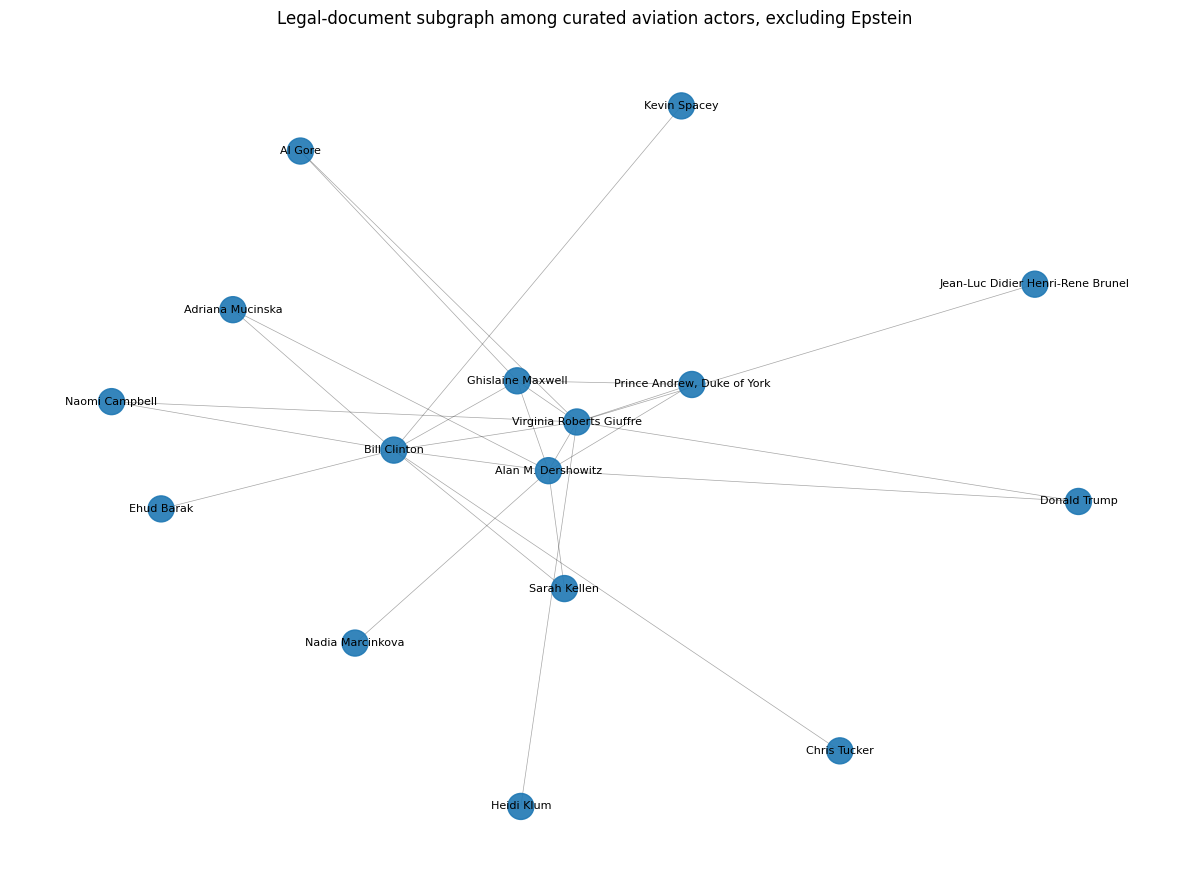

In [184]:
plt.figure(figsize=(12, 9))

pos = nx.spring_layout(G_legal, seed=42, k=1.0)

edge_widths = [
    0.5 #+ 0.7 * G_legal[u][v]["weight"]
    for u, v in G_legal.edges()
]

weighted_degree = dict(G_legal.degree(weight="weight"))

node_sizes = [
    350 #+ 100 * weighted_degree[n]
    for n in G_legal.nodes()
]

nx.draw_networkx_edges(
    G_legal,
    pos,
    width=edge_widths,
    alpha=0.35
)

nx.draw_networkx_nodes(
    G_legal,
    pos,
    node_size=node_sizes,
    alpha=0.9
)

nx.draw_networkx_labels(
    G_legal,
    pos,
    font_size=8
)

plt.title("Legal-document subgraph among curated aviation actors, excluding Epstein")
plt.axis("off")
plt.tight_layout()
plt.show()

## PART 5: Network Analysis

### centrality measures

In [187]:
# ============================================================
# FULL NETWORK (excluding Epstein)
# ============================================================

G_full_analysis = G_aviation.copy()

if "Jeffrey Epstein" in G_full_analysis.nodes:
    G_full_analysis.remove_node("Jeffrey Epstein")

print("FULL NETWORK (excluding Epstein)")
print(f"Nodes: {G_full_analysis.number_of_nodes():,}")
print(f"Edges: {G_full_analysis.number_of_edges():,}")


# Centrality metrics

degree_full = dict(G_full_analysis.degree(weight="weight"))

betweenness_full = nx.betweenness_centrality(
    G_full_analysis,
    weight="weight"
)

pagerank_full = nx.pagerank(
    G_full_analysis,
    weight="weight"
)

eigenvector_full = nx.eigenvector_centrality(
    G_full_analysis,
    weight="weight",
    max_iter=1000
)


# Build dataframe

df_metrics_full = pd.DataFrame({
    "entity": list(G_full_analysis.nodes()),
    "degree_full": [degree_full[n] for n in G_full_analysis.nodes()],
    "betweenness_full": [betweenness_full[n] for n in G_full_analysis.nodes()],
    "pagerank_full": [pagerank_full[n] for n in G_full_analysis.nodes()],
    "eigenvector_full": [eigenvector_full[n] for n in G_full_analysis.nodes()]
})

df_metrics_full = (
    df_metrics_full
    .sort_values("pagerank_full", ascending=False)
    .reset_index(drop=True)
)

print("\nTop full-network actors:")
print(df_metrics_full.head(22))

FULL NETWORK (excluding Epstein)
Nodes: 22
Edges: 38

Top full-network actors:
                               entity  degree_full  betweenness_full  \
0            Virginia Roberts Giuffre        295.0          0.095238   
1                        Bill Clinton        198.0          0.366667   
2                   Ghislaine Maxwell        213.0          0.100000   
3                  Alan M. Dershowitz        137.0          0.019048   
4                          Ehud Barak        104.0          0.133333   
5         Prince Andrew, Duke of York        107.0          0.028571   
6                        Donald Trump         80.0          0.000000   
7                    Lawrence Summers         25.0          0.150000   
8                      Naomi Campbell          8.0          0.138095   
9                        Sarah Kellen         12.0          0.042857   
10                            Al Gore         12.0          0.033333   
11  Jean-Luc Didier Henri-Rene Brunel          4.0       

In [188]:
# ============================================================
# LEGAL-ONLY NETWORK (excluding Epstein)
# ============================================================

print("LEGAL NETWORK")
print(f"Nodes: {G_legal.number_of_nodes():,}")
print(f"Edges: {G_legal.number_of_edges():,}")


# Centrality metrics

degree_legal = dict(G_legal.degree(weight="weight"))

betweenness_legal = nx.betweenness_centrality(
    G_legal,
    weight="weight"
)

pagerank_legal = nx.pagerank(
    G_legal,
    weight="weight"
)

eigenvector_legal = nx.eigenvector_centrality(
    G_legal,
    weight="weight",
    max_iter=1000
)


# Build dataframe

df_metrics_legal = pd.DataFrame({
    "entity": list(G_legal.nodes()),
    "degree_legal": [degree_legal[n] for n in G_legal.nodes()],
    "betweenness_legal": [betweenness_legal[n] for n in G_legal.nodes()],
    "pagerank_legal": [pagerank_legal[n] for n in G_legal.nodes()],
    "eigenvector_legal": [eigenvector_legal[n] for n in G_legal.nodes()]
})

df_metrics_legal = (
    df_metrics_legal
    .sort_values("pagerank_legal", ascending=False)
    .reset_index(drop=True)
)

print("\nTop legal-network actors:")
print(df_metrics_legal.head(15))

LEGAL NETWORK
Nodes: 16
Edges: 25

Top legal-network actors:
                               entity  degree_legal  betweenness_legal  \
0            Virginia Roberts Giuffre         149.0           0.490476   
1                  Alan M. Dershowitz          85.0           0.490476   
2                   Ghislaine Maxwell          69.0           0.004762   
3                        Bill Clinton          44.0           0.400000   
4         Prince Andrew, Duke of York          34.0           0.000000   
5                          Ehud Barak          10.0           0.000000   
6                        Sarah Kellen           7.0           0.000000   
7                      Naomi Campbell           5.0           0.095238   
8                    Adriana Mucinska           4.0           0.000000   
9                    Nadia Marcinkova           4.0           0.000000   
10                       Donald Trump           2.0           0.347619   
11  Jean-Luc Didier Henri-Rene Brunel           2.0

In [189]:
# ============================================================
# COMBINED NODE METRICS TABLE
# ============================================================

df_metrics_combined = pd.merge(
    df_metrics_full,
    df_metrics_legal,
    on="entity",
    how="outer"
).fillna(0)

df_metrics_combined = (
    df_metrics_combined
    .sort_values("pagerank_full", ascending=False)
    .reset_index(drop=True)
)

metric_cols = [
    "degree_full",
    "betweenness_full",
    "pagerank_full",
    "eigenvector_full",
    "degree_legal",
    "betweenness_legal",
    "pagerank_legal",
    "eigenvector_legal"
]

df_metrics_combined[metric_cols] = (
    df_metrics_combined[metric_cols]
    .round(3)
)

print(df_metrics_combined.head(20))

                               entity  degree_full  betweenness_full  \
0            Virginia Roberts Giuffre        295.0             0.095   
1                        Bill Clinton        198.0             0.367   
2                   Ghislaine Maxwell        213.0             0.100   
3                  Alan M. Dershowitz        137.0             0.019   
4                          Ehud Barak        104.0             0.133   
5         Prince Andrew, Duke of York        107.0             0.029   
6                        Donald Trump         80.0             0.000   
7                    Lawrence Summers         25.0             0.150   
8                      Naomi Campbell          8.0             0.138   
9                        Sarah Kellen         12.0             0.043   
10                            Al Gore         12.0             0.033   
11  Jean-Luc Didier Henri-Rene Brunel          4.0             0.000   
12                   Nadia Marcinkova          7.0             0

### Graph Analysis

In [190]:
def graph_summary(G):

    largest_cc = max(nx.connected_components(G), key=len)
    G_lcc = G.subgraph(largest_cc).copy()

    return {

        "nodes": G.number_of_nodes(),

        "edges": G.number_of_edges(),

        "density": nx.density(G),

        "connected_components": nx.number_connected_components(G),

        "average_clustering": nx.average_clustering(G),

        "largest_component_size": len(largest_cc),

        "diameter_lcc": nx.diameter(G_lcc),

        "average_path_length_lcc": nx.average_shortest_path_length(G_lcc)
    }

summary_full = graph_summary(G_aviation_no_epstein)
summary_legal = graph_summary(G_legal)

df_network_summary = pd.DataFrame(
    [summary_full, summary_legal],
    index=["full_network", "legal_network"]
)

df_network_summary = df_network_summary.round(3)

df_network_summary

,nodes,edges,density,connected_components,average_clustering,largest_component_size,diameter_lcc,average_path_length_lcc
full_network,22,38,0.165,5,0.419,18,3,1.974
legal_network,16,25,0.208,1,0.455,16,3,2.025


note, the legal network is fully connected, where the broader network is not. Density increases. Average path length is stable despite reduction in nodes, indicating core of original network is still present

In [193]:
import networkx as nx

# Build graph from Gephi export
G = nx.Graph()

# Add nodes
G.add_nodes_from(df_gephi_nodes["Id"])

# Add weighted edges
for _, row in df_gephi_edges.iterrows():
    G.add_edge(
        row["Source"],
        row["Target"],
        weight=row["Weight"]
    )

# Apply summary function
summary = graph_summary(G)

summary

{'nodes': 18,
 'edges': 38,
 'density': 0.24836601307189543,
 'connected_components': 1,
 'average_clustering': 0.5119087702421035,
 'largest_component_size': 18,
 'diameter_lcc': 3,
 'average_path_length_lcc': 1.973856209150327}

In [195]:
centrality_df = pd.DataFrame({
    "actor": list(G.nodes()),
    "degree": pd.Series(dict(G.degree())),
    "pagerank": pd.Series(nx.pagerank(G, weight="weight")),
    "betweenness": pd.Series(nx.betweenness_centrality(G, weight="weight"))
})

centrality_df.sort_values("pagerank", ascending=False)

,actor,degree,pagerank,betweenness
Virginia Roberts Giuffre,Virginia Roberts Giuffre,9,0.303225,0.490476
Alan M. Dershowitz,Alan M. Dershowitz,8,0.177916,0.490476
Ghislaine Maxwell,Ghislaine Maxwell,5,0.139147,0.004762
Bill Clinton,Bill Clinton,9,0.126182,0.400000
"Prince Andrew, Duke of York","Prince Andrew, Duke of York",3,0.068258,0.000000
Ehud Barak,Ehud Barak,1,0.033752,0.000000
Sarah Kellen,Sarah Kellen,2,0.023805,0.000000
Naomi Campbell,Naomi Campbell,2,0.020148,0.095238
Adriana Mucinska,Adriana Mucinska,2,0.017809,0.000000
Nadia Marcinkova,Nadia Marcinkova,1,0.016492,0.000000


In [194]:
import networkx as nx

# Build graph from Gephi export
G = nx.Graph()

# Add nodes
G.add_nodes_from(df_gephi_nodes_legal["Id"])

# Add weighted edges
for _, row in df_gephi_edges_legal.iterrows():
    G.add_edge(
        row["Source"],
        row["Target"],
        weight=row["Weight"]
    )

# Apply summary function
summary = graph_summary(G)

summary

{'nodes': 16,
 'edges': 25,
 'density': 0.20833333333333334,
 'connected_components': 1,
 'average_clustering': 0.4546626984126984,
 'largest_component_size': 16,
 'diameter_lcc': 3,
 'average_path_length_lcc': 2.025}

### Community detection

In [127]:
from networkx.algorithms.community import greedy_modularity_communities

communities = greedy_modularity_communities(
    G_aviation_no_epstein,
    weight="weight"
)

community_map = {}

for i, community in enumerate(communities):

    for node in community:

        community_map[node] = i

df_communities = pd.DataFrame({
    "entity": list(community_map.keys()),
    "community": list(community_map.values())
})

df_communities.sort_values("community")

,entity,community
0,Ghislaine Maxwell,0
1,Virginia Roberts Giuffre,0
2,"Prince Andrew, Duke of York",0
3,Heidi Klum,0
4,Alan M. Dershowitz,0
5,Nadia Marcinkova,0
6,Al Gore,0
13,Sarah Kellen,1
12,Chris Tucker,1
11,Sandy Berger,1


## PART 6: Gephi Node/Edge Generation and export

### Full Aviation Network

In [191]:
# ============================================================
# Gephi export: Full Aviation Edges
# ============================================================

df_gephi_edges = df_aviation_edges.copy()

df_gephi_edges = df_gephi_edges[[
    "source",
    "target",
    "weight",
    "legal_prop",
    "legal_weight",
    "dominant_document_group"
]].rename(columns={
    "source": "Source",
    "target": "Target",
    "weight": "Weight"
})

df_gephi_edges["Type"] = "Undirected"

df_gephi_edges = (
    df_gephi_edges[
        (df_gephi_edges["Source"] != "Jeffrey Epstein") &
        (df_gephi_edges["Target"] != "Jeffrey Epstein")
    ]
    .copy()
)

df_gephi_edges.to_csv(
    "gephi_edges.csv",
    index=False
)

print(df_gephi_edges.head())

             Source                    Target  Weight  legal_prop  \
0  Adriana Mucinska        Alan M. Dershowitz       2    1.000000   
1  Adriana Mucinska              Bill Clinton       3    0.666667   
3           Al Gore         Ghislaine Maxwell       3    0.333333   
5           Al Gore          Lawrence Summers       1    0.000000   
6           Al Gore  Virginia Roberts Giuffre       8    0.125000   

   legal_weight dominant_document_group        Type  
0             2                   legal  Undirected  
1             2                   legal  Undirected  
3             1                   media  Undirected  
5             0           communication  Undirected  
6             1                   media  Undirected  


In [192]:
# ============================================================
# Gephi export: nodes
# ============================================================

all_nodes = sorted(
    set(df_gephi_edges["Source"]).union(set(df_gephi_edges["Target"]))
)

df_gephi_nodes = pd.DataFrame({
    "Id": all_nodes,
    "Label": all_nodes
})

# Add full/legal metrics
df_gephi_nodes = df_gephi_nodes.merge(
    df_metrics_combined,
    left_on="Id",
    right_on="entity",
    how="left"
).drop(columns=["entity"], errors="ignore")

# Add actor categories to node table

df_gephi_nodes["actor_category"] = (
    df_gephi_nodes["Label"]
    .map(ACTOR_CATEGORY_MAP)
    .fillna("other")
)

df_gephi_nodes = df_gephi_nodes.fillna(0)

df_gephi_nodes.to_csv("gephi_nodes.csv", index=False)

print("Saved: gephi_nodes.csv")
print(df_gephi_nodes)

Saved: gephi_nodes.csv
                                   Id                              Label  \
0                    Adriana Mucinska                   Adriana Mucinska   
1                             Al Gore                            Al Gore   
2                  Alan M. Dershowitz                 Alan M. Dershowitz   
3                        Bill Clinton                       Bill Clinton   
4                        Chris Tucker                       Chris Tucker   
5                        Donald Trump                       Donald Trump   
6                          Ehud Barak                         Ehud Barak   
7                   Ghislaine Maxwell                  Ghislaine Maxwell   
8                          Heidi Klum                         Heidi Klum   
9   Jean-Luc Didier Henri-Rene Brunel  Jean-Luc Didier Henri-Rene Brunel   
10                       Kevin Spacey                       Kevin Spacey   
11                   Lawrence Summers                   Lawrence 

### Legal Network

In [134]:
# ============================================================
# Gephi export: legal edges
# ============================================================

df_gephi_edges_legal = df_legal_subgraph_edges.copy()

df_gephi_edges_legal = df_gephi_edges_legal[[
    "source",
    "target",
    "weight",
    "legal_prop",
    "legal_weight",
    "dominant_document_group"
]].rename(columns={
    "source": "Source",
    "target": "Target",
    "weight": "Weight"
})

df_gephi_edges_legal["Type"] = "Undirected"

df_gephi_edges_legal = (
    df_gephi_edges_legal[
        (df_gephi_edges_legal["Source"] != "Jeffrey Epstein") &
        (df_gephi_edges_legal["Target"] != "Jeffrey Epstein")
    ]
    .copy()
)

df_gephi_edges_legal.to_csv(
    "gephi_edges_legal.csv",
    index=False
)

print(df_gephi_edges_legal.head())

               Source                    Target  Weight  legal_prop  \
0    Adriana Mucinska        Alan M. Dershowitz       2         1.0   
1    Adriana Mucinska              Bill Clinton       2         1.0   
2             Al Gore         Ghislaine Maxwell       1         1.0   
3             Al Gore  Virginia Roberts Giuffre       1         1.0   
4  Alan M. Dershowitz              Bill Clinton       3         1.0   

   legal_weight dominant_document_group        Type  
0             2                   legal  Undirected  
1             2                   legal  Undirected  
2             1                   legal  Undirected  
3             1                   legal  Undirected  
4             3                   legal  Undirected  


In [135]:
# ============================================================
# Gephi export: legalnodes
# ============================================================

all_node_legal = sorted(
    set(df_gephi_edges_legal["Source"]).union(set(df_gephi_edges_legal["Target"]))
)

df_gephi_nodes_legal = pd.DataFrame({
    "Id": all_node_legal,
    "Label": all_node_legal
})

# Add full/legal metrics
df_gephi_nodes_legal = df_gephi_nodes_legal.merge(
    df_metrics_combined,
    left_on="Id",
    right_on="entity",
    how="left"
).drop(columns=["entity"], errors="ignore")

# Add actor categories to node table

df_gephi_nodes_legal["actor_category"] = (
    df_gephi_nodes_legal["Label"]
    .map(ACTOR_CATEGORY_MAP)
    .fillna("other")
)

df_gephi_nodes_legal = df_gephi_nodes_legal.fillna(0)

df_gephi_nodes_legal.to_csv("gephi_nodes_legal.csv", index=False)

print("Saved: gephi_nodes_legal.csv")
print(df_gephi_nodes_legal.head())

Saved: gephi_nodes_legal.csv
                   Id               Label  degree_full  betweenness_full  \
0    Adriana Mucinska    Adriana Mucinska          5.0             0.043   
1             Al Gore             Al Gore         12.0             0.033   
2  Alan M. Dershowitz  Alan M. Dershowitz        137.0             0.019   
3        Bill Clinton        Bill Clinton        198.0             0.367   
4        Chris Tucker        Chris Tucker          4.0             0.000   

   pagerank_full  eigenvector_full  degree_legal  betweenness_legal  \
0          0.011             0.009           4.0              0.000   
1          0.015             0.034           2.0              0.124   
2          0.100             0.357          85.0              0.490   
3          0.158             0.340          44.0              0.400   
4          0.011             0.007           1.0              0.000   

   pagerank_legal  eigenvector_legal  pagerank_delta     actor_category  
0           0

## PART 7:: Visuals

### Document Provenence before aggregation

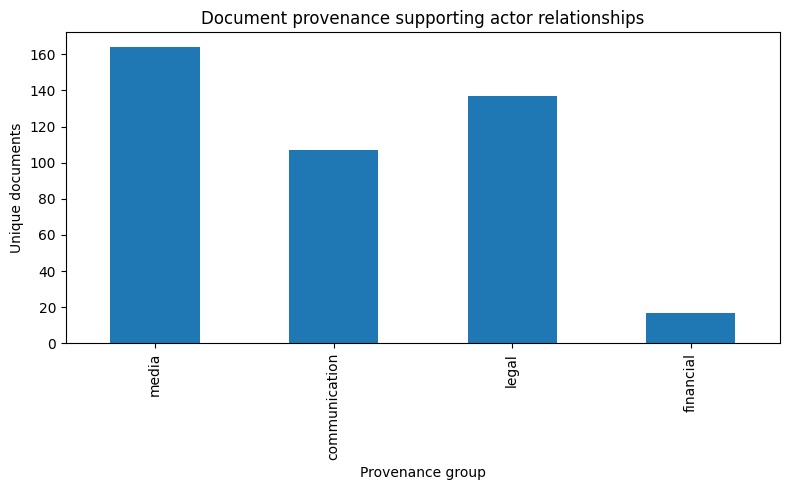

In [163]:
import matplotlib.pyplot as plt

prov_counts = (
    df_aviation_full_events
    .query("node_1 != 'Jeffrey Epstein' and node_2 != 'Jeffrey Epstein'")
    [["doc_id", "document_group"]]
    .drop_duplicates()
    .query("document_group in ['communication', 'media', 'legal', 'financial']")
    .groupby("document_group")
    .size()
    .reindex(["media", "communication", "legal", "financial"])
)

plt.figure(figsize=(8, 5))
prov_counts.plot(kind="bar")

plt.title("Document provenance supporting actor relationships")
plt.xlabel("Provenance group")
plt.ylabel("Unique documents")

plt.tight_layout()
plt.show()

### Comparing Pagerank in full & legal only networks

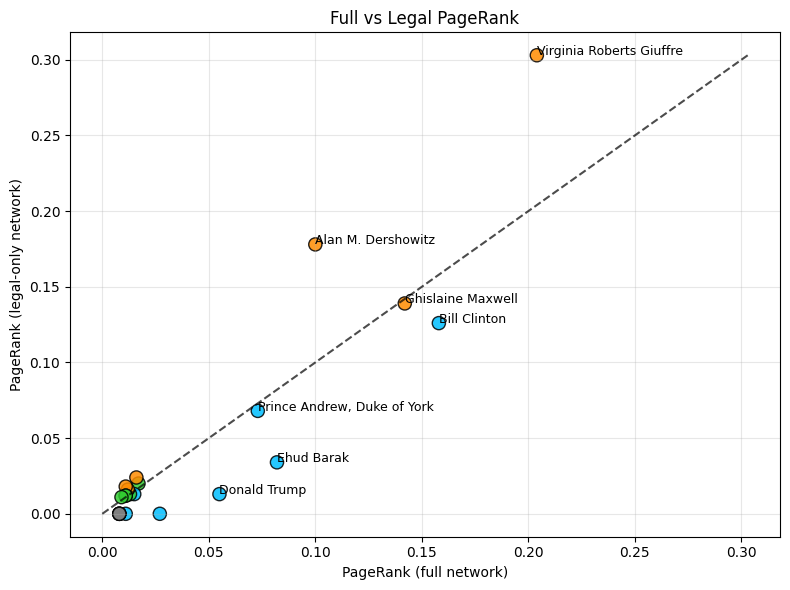

In [122]:
# Merge actor categories onto metrics table

plot_df = df_metrics_combined.merge(
    df_gephi_nodes[["Label", "actor_category"]],
    left_on="entity",
    right_on="Label",
    how="left"
)

# Stronger category colors

category_colors = {
    "political": "deepskyblue",
    "Epstein associate": "darkorange",
    "celebrity/media": "limegreen"
}

# Default fallback color
default_color = "grey"

# Build color vector
colors = [
    category_colors.get(cat, default_color)
    for cat in plot_df["actor_category"]
]

# Scatterplot

plt.figure(figsize=(8, 6))

x = plot_df["pagerank_full"]
y = plot_df["pagerank_legal"]

plt.scatter(
    x,
    y,
    c=colors,
    edgecolors="black",
    alpha=0.85,
    s=90
)

# y = x reference line

lims = [
    min(x.min(), y.min()),
    max(x.max(), y.max())
]

plt.plot(
    lims,
    lims,
    linestyle="--",
    color="black",
    alpha=0.7
)

# Label actors with notable PageRank

for _, row in plot_df.iterrows():

    if (
        row["pagerank_full"] > 0.05
        or row["pagerank_legal"] > 0.05
    ):

        plt.text(
            row["pagerank_full"],
            row["pagerank_legal"],
            row["entity"],
            fontsize=9
        )

plt.xlabel("PageRank (full network)")
plt.ylabel("PageRank (legal-only network)")
plt.title("Full vs Legal PageRank")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

certain actors become more important in the legal network (the lawyer and main litigant), and others become less so- famous politicians with a large media presence.

In [128]:
df_metrics_combined["pagerank_delta"] = (
    df_metrics_combined["pagerank_legal"] -
    df_metrics_combined["pagerank_full"]
)

pagerank_shift = (
    df_metrics_combined[
        ["entity", "pagerank_full", "pagerank_legal", "pagerank_delta"]
    ]
    .sort_values("pagerank_delta", ascending=False)
)

print("Largest increases in legal network")
display(pagerank_shift.head(10))

print("Largest decreases in legal network")
display(pagerank_shift.tail(10))

Largest increases in legal network


,entity,pagerank_full,pagerank_legal,pagerank_delta
0,Virginia Roberts Giuffre,0.204,0.303,0.099
3,Alan M. Dershowitz,0.100,0.178,0.078
9,Sarah Kellen,0.016,0.024,0.008
13,Adriana Mucinska,0.011,0.018,0.007
12,Nadia Marcinkova,0.012,0.016,0.004
8,Naomi Campbell,0.017,0.020,0.003
17,Heidi Klum,0.009,0.011,0.002
15,Chris Tucker,0.011,0.012,0.001
14,Kevin Spacey,0.011,0.012,0.001
11,Jean-Luc Didier Henri-Rene Brunel,0.013,0.013,0.000


Largest decreases in legal network


,entity,pagerank_full,pagerank_legal,pagerank_delta
5,"Prince Andrew, Duke of York",0.073,0.068,-0.005
18,Haley Robson,0.008,0.000,-0.008
19,Bill Richardson,0.008,0.000,-0.008
20,Andrés Pastrana Arango,0.008,0.000,-0.008
21,Thorbjørn Jagland,0.008,0.000,-0.008
16,Sandy Berger,0.011,0.000,-0.011
7,Lawrence Summers,0.027,0.000,-0.027
1,Bill Clinton,0.158,0.126,-0.032
6,Donald Trump,0.055,0.013,-0.042
4,Ehud Barak,0.082,0.034,-0.048


### Comparing Document Provenance within the aviation network

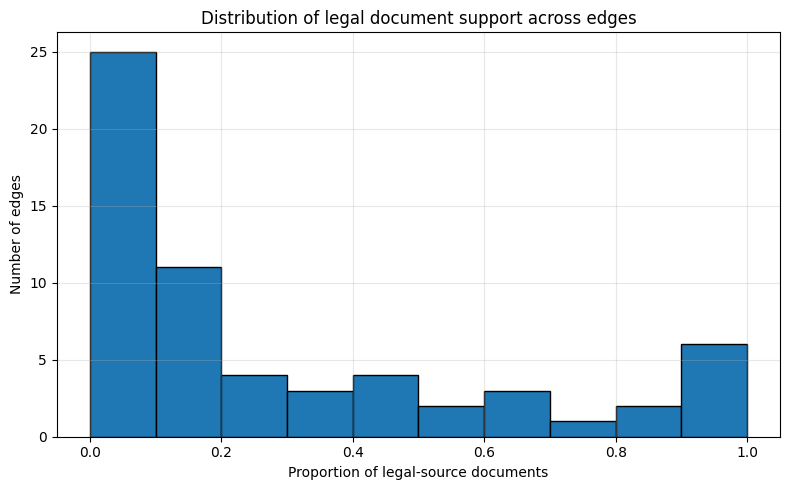

In [166]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_aviation_edges["legal_prop"],
    bins=10,
    edgecolor="black"
)

plt.xlabel("Proportion of legal-source documents")
plt.ylabel("Number of edges")

plt.title("Distribution of legal document support across edges")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

dominant document categories

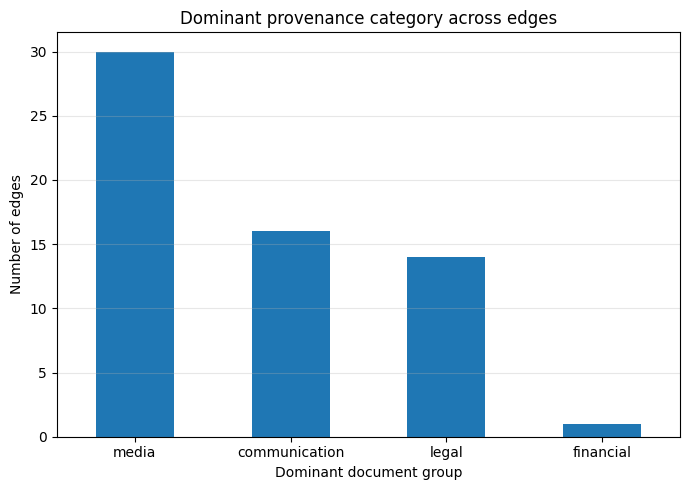

In [131]:
doc_group_counts = (
    df_aviation_edges["dominant_document_group"]
    .value_counts()
)

plt.figure(figsize=(7, 5))

doc_group_counts.plot(
    kind="bar"
)

plt.ylabel("Number of edges")

plt.xlabel("Dominant document group")

plt.title("Dominant provenance category across edges")

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Gephi Networks

Full Network

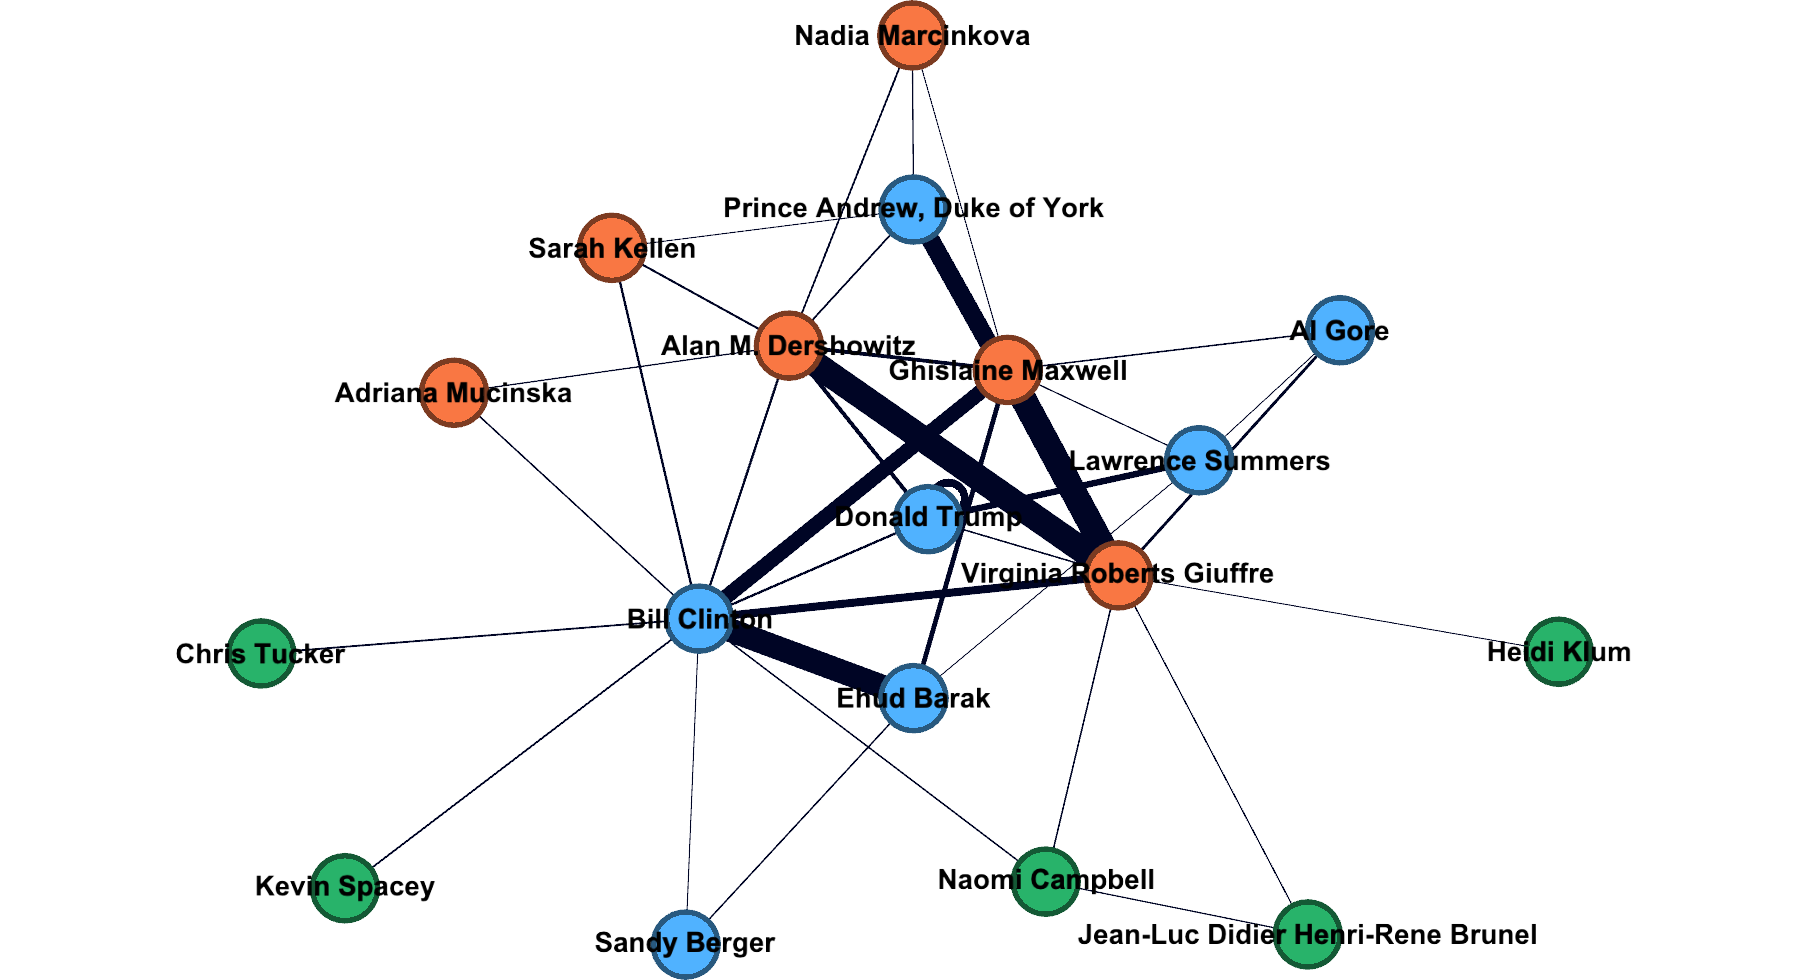

In [113]:
display(Image(filename="png_gephi/Dave_Aviation_Full_Weighted_Gephi.png"))

legal only

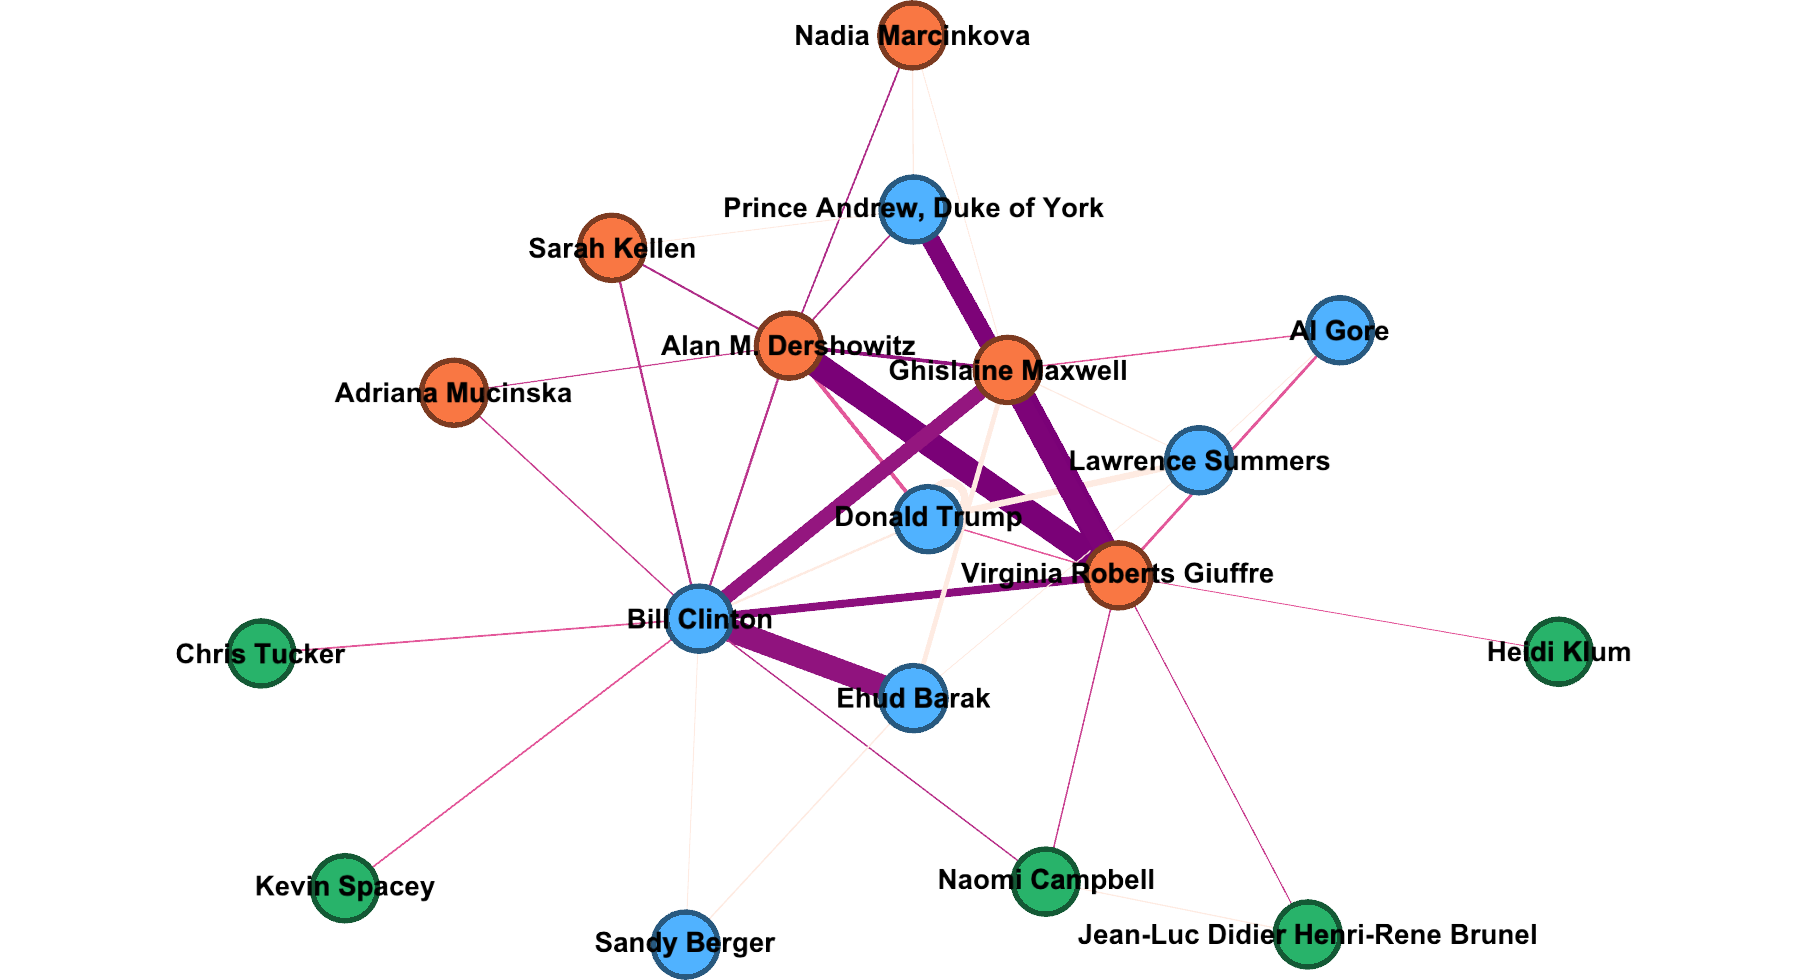

In [116]:
display(Image(filename="png_gephi/Dave_Aviation_Legal_Weighted_Gephi.png"))